In [1]:
pip install moabb mne torch scikit-learn moabb

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import os
import torch
import warnings
import urllib3
import gc
import time
import sys
import moabb
from moabb.datasets import Cho2017
from moabb.paradigms import MotorImagery
import mne
import pooch.downloaders as pooch_downloaders

# Force verbose logging for MOABB and MNE.
moabb.set_log_level('info')
mne.set_log_level('info')

# Suppress InsecureRequestWarning for HTTP downloads
warnings.filterwarnings("ignore", category=urllib3.exceptions.InsecureRequestWarning)

def _format_bytes(num_bytes):
    units = ['B', 'KB', 'MB', 'GB', 'TB']
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f"{value:.1f} {unit}" if unit != 'B' else f"{int(value)} {unit}"
        value /= 1024

class NotebookDownloadProgress:
    def __init__(self, total=0, unit='B', unit_scale=True, **kwargs):
        self.total = total or 0
        self.n = 0
        self.unit = unit
        self.unit_scale = unit_scale
        self.started_at = time.time()
        self.last_render_at = 0.0
        self.last_pct = -1
        self._render(force=True)

    def _render(self, force=False):
        now = time.time()
        if not force and now - self.last_render_at < 0.2:
            return
        self.last_render_at = now
        total = max(int(self.total), 0)
        downloaded = min(int(self.n), total) if total else int(self.n)
        pct = int((downloaded / total) * 100) if total else 0
        if not force and pct == self.last_pct:
            return
        self.last_pct = pct
        elapsed = max(now - self.started_at, 1e-9)
        rate = downloaded / elapsed
        rate_text = f"{_format_bytes(rate)}/s" if downloaded else "starting..."
        total_text = _format_bytes(total) if total else 'unknown'
        current_text = _format_bytes(downloaded)
        filled = int((pct / 100) * 30) if total else 0
        bar = '#' * filled + '-' * (30 - filled)
        message = f"[{bar}] {pct:3d}% | {current_text} / {total_text} | {rate_text}"
        sys.stdout.write('\r' + message)
        sys.stdout.flush()

    def update(self, amount):
        self.n += amount
        self._render()

    def reset(self):
        self.n = 0
        self.started_at = time.time()
        self.last_pct = -1
        self._render(force=True)

    def close(self):
        self._render(force=True)
        sys.stdout.write('\n')
        sys.stdout.flush()

# Pooch defaults to terminal-style tqdm output, which renders as raw ANSI in Jupyter.
# Replacing its tqdm factory gives us a notebook-safe progress UI for MOABB downloads.
pooch_downloaders.tqdm = NotebookDownloadProgress

# Set MNE data path to an absolute local directory so it caches raw downloads predictably on Windows.
mne_data_dir = os.path.abspath(os.path.join(os.getcwd(), 'mne_data'))
os.makedirs(mne_data_dir, exist_ok=True)
mne.set_config('MNE_DATA', mne_data_dir)
moabb.set_download_dir(mne_data_dir)  # FORCE moabb to use the local directory

# 1. Initialize the dataset & paradigm
dataset = Cho2017()
paradigm = MotorImagery(fmin=8, fmax=32)

# 2. Iterate through each subject to download and save locally (if not cached)
os.makedirs('processed_data', exist_ok=True)

print("Checking and downloading missing subjects...")

# Download each missing subject individually so notebook progress stays visible and cached files are reused.
for sub in dataset.subject_list:
    file_path = f"processed_data/subject_{sub}.pt"
    
    if not os.path.exists(file_path):
        print(f"\n=========================================")
        print(f"   Downloading and Processing Subject {sub}  ")
        print(f"=========================================")
        try:
            # Trigger the download explicitly so the notebook-safe Pooch progress bar is shown first.
            dataset.data_path(sub)
            
            # Fetch data for just this subject (instantly uses the downloaded files)
            X_sub, y_sub, _ = paradigm.get_data(dataset=dataset, subjects=[sub])
            # Save the extracted epoch numpy arrays to a local PyTorch file
            torch.save((X_sub, y_sub), file_path)
            
            # Explicitly force garbage collection to prevent memory-leak stalling 
            del X_sub, y_sub, _
            gc.collect()
            
        except Exception as e:
            print(f"Skipping Subject {sub} due to download/processing error: {e}")
            continue

print("\nAll downloads complete or cached.")

c:\Users\sunny\miniconda3\envs\bci\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-24 23:30:34,891 WARNING MainThread moabb.paradigms.motor_imagery Choosing from all possible events


Checking and downloading missing subjects...

All downloads complete or cached.


In [3]:
import torch
from torch.utils.data import Dataset
from pathlib import Path
import numpy as np
from sklearn.preprocessing import LabelEncoder

class EEGCacheDataset(Dataset):
    def __init__(self, data_dir="processed_data", num_subjects=5):
        """
        Loads cached EEG subject data and prepares it for mini-batching.
        """
        self.data_dir = Path(data_dir)
        cache_files = sorted(
            self.data_dir.glob("subject_*.pt"),
            key=lambda path: int(path.stem.split("_")[-1])
        )
        
        self.cache_files = cache_files[:num_subjects]
        self.encoder = LabelEncoder()
        
        print(f"Loading {len(self.cache_files)} subjects from local cache...")
        X_list, y_list = [], []
        
        for i, file_path in enumerate(self.cache_files):
            print(f"\rLoading {file_path.name} ({i+1}/{len(self.cache_files)})...", end="", flush=True)
            X_sub, y_sub = torch.load(file_path, weights_only=False)
            X_list.append(X_sub)
            y_list.extend(y_sub)
            
        print(f"\nSuccessfully loaded {len(self.cache_files)} subjects.")
        
        if len(X_list) > 0:
            # Combine
            X_combined = np.concatenate(X_list, axis=0)
            y_combined = np.array(y_list)
            
            # Encode labels to integers
            y_encoded = self.encoder.fit_transform(y_combined)
            
            # Convert to PyTorch tensors and add channel dimension: (Trials, 1, Channels, Timepoints)
            self.X_tensor = torch.tensor(X_combined, dtype=torch.float32).unsqueeze(1)
            self.y_tensor = torch.tensor(y_encoded, dtype=torch.long)
            self.num_classes = len(self.encoder.classes_)
            self.n_channels = self.X_tensor.shape[2]
            self.n_timepoints = self.X_tensor.shape[3]
            
            print(f"Dataset Tensor Shape: {self.X_tensor.shape}") 
            print(f"Labels Tensor Shape: {self.y_tensor.shape}")
        else:
            self.X_tensor, self.y_tensor = torch.empty(0), torch.empty(0)
            self.num_classes = 0
            print("No data was successfully loaded.")

    def __len__(self):
        return len(self.X_tensor)

    def __getitem__(self, idx):
        return self.X_tensor[idx], self.y_tensor[idx]

# Example initialization:
# dataset = EEGCacheDataset(data_dir="processed_data", num_subjects=5)

In [4]:
import torch
from torch.utils.data import DataLoader, random_split

# Initialize the full dataset using the new class
full_dataset = EEGCacheDataset(data_dir="processed_data", num_subjects=52)

# Split into train/validation sets (80% train, 20% val)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size], 
    generator=torch.Generator().manual_seed(42)
)

# Create mini-batch DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Loading 52 subjects from local cache...
Loading subject_52.pt (52/52)...
Successfully loaded 52 subjects.
Dataset Tensor Shape: torch.Size([10520, 1, 64, 1537])
Labels Tensor Shape: torch.Size([10520])


In [5]:
import torch.nn as nn

class EEGTransformer(nn.Module):
    def __init__(self, n_channels, n_timepoints, n_classes, d_model=64, n_heads=8, n_layers=4):
        super(EEGTransformer, self).__init__()
        
        # 1. Temporal & Spatial Feature Extraction (CNN Front-end)
        self.conv_block = nn.Sequential(
            # Temporal Convolution
            nn.Conv2d(1, 40, kernel_size=(1, 25), padding=(0, 12)),
            # Spatial Convolution (Across all EEG channels)
            nn.Conv2d(40, 40, kernel_size=(n_channels, 1), bias=False),
            nn.BatchNorm2d(40),
            nn.ELU(),
            # Temporal Pooling to create sequence tokens
            nn.AvgPool2d(kernel_size=(1, 15), stride=(1, 15)),
            nn.Dropout(0.5)
        )
        
        # Calculate sequence length after the AvgPool2d
        seq_len = n_timepoints // 15
        
        # 2. Token Projection & Positional Encoding
        self.projection = nn.Linear(40, d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len + 1, d_model))
        
        # 3. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_heads, 
            dim_feedforward=256,
            batch_first=True,
            dropout=0.3
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # 4. Classification Head
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, n_classes)
        )

    def forward(self, x):
        # Extract features: Output shape -> (Batch, 40, 1, Seq_Len)
        x = self.conv_block(x)
        
        # Reshape for Transformer: Output shape -> (Batch, Seq_Len, 40)
        x = x.squeeze(2).permute(0, 2, 1)
        
        # Project to d_model space -> (Batch, Seq_Len, d_model)
        x = self.projection(x)
        
        # Append CLS token -> (Batch, Seq_Len + 1, d_model)
        b = x.shape[0]
        cls_tokens = self.cls_token.expand(b, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        
        # Add Positional Embeddings
        x += self.pos_embedding
        
        # Apply Transformer Encoder
        x = self.transformer(x)
        
        # Extract the state of the CLS token for classification
        cls_out = x[:, 0, :]
        
        return self.classifier(cls_out)

In [6]:
# Extract parameters from the dataset directly
n_channels = full_dataset.n_channels
n_timepoints = full_dataset.n_timepoints
n_classes = full_dataset.num_classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EEGTransformer(n_channels=n_channels, n_timepoints=n_timepoints, n_classes=n_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Training loop with mini-batches
epochs = 50
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Debug statement for batch progress
        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == len(train_loader):
            print(f"\rEpoch [{epoch+1}/{epochs}] | Batch [{batch_idx+1}/{len(train_loader)}] | Current Loss: {loss.item():.4f}", end="")
            
    # Print a newline at the end of the epoch to not overwrite the batch progress text on next validation print
    print()
    
    if (epoch + 1) % 10 == 0:
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        print(f"Epoch {epoch+1}/{epochs} | Avg Loss: {running_loss/len(train_loader):.4f} | Val Accuracy: {100 * correct / total:.2f}%\n")

Epoch [1/50] | Batch [200/263] | Current Loss: 0.6919

KeyboardInterrupt: 

Training on 10% of the training data...
Validation Accuracy (Evaluated on fixed 20% holdout set) for 10% train data: 52.00%

Training on 20% of the training data...
Validation Accuracy (Evaluated on fixed 20% holdout set) for 20% train data: 56.00%

Training on 40% of the training data...
Validation Accuracy (Evaluated on fixed 20% holdout set) for 40% train data: 57.00%

Training on 60% of the training data...
Validation Accuracy (Evaluated on fixed 20% holdout set) for 60% train data: 69.50%

Training on 80% of the training data...
Validation Accuracy (Evaluated on fixed 20% holdout set) for 80% train data: 67.00%

Training on 100% of the training data...
Validation Accuracy (Evaluated on fixed 20% holdout set) for 100% train data: 71.50%



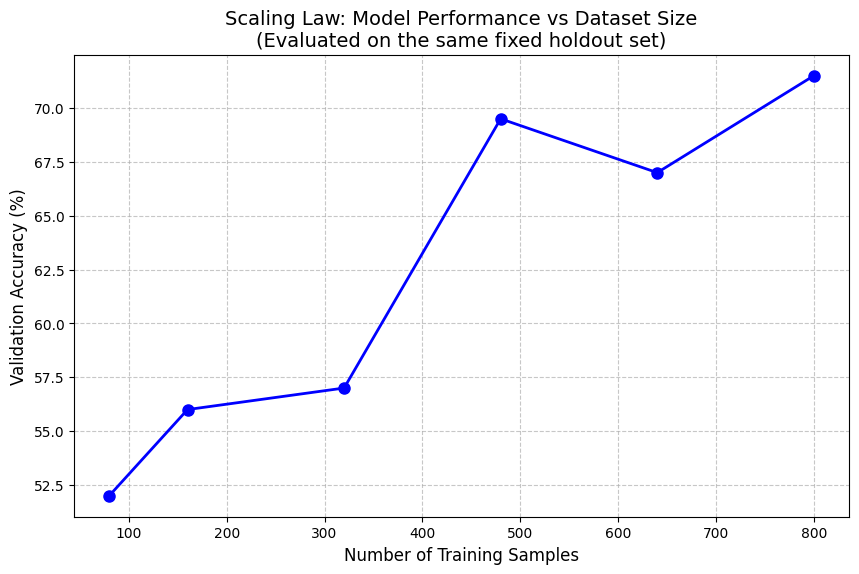

In [ ]:
import matplotlib.pyplot as plt
from torch.utils.data import Subset

# Extract parameters from the dataset directly
n_channels = full_dataset.n_channels
n_timepoints = full_dataset.n_timepoints
n_classes = full_dataset.num_classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Fractions of training data to use
data_fractions = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
val_accuracies = []

epochs_scaling = 100 # Adjust epochs as needed

for frac in data_fractions:
    print(f"Training on {int(frac*100)}% of the training data...")
    
    # Subset the training dataset dynamically
    num_samples = int(len(train_dataset) * frac)
    subset_indices = list(range(num_samples))
    train_subset = Subset(train_dataset, subset_indices)
    
    subset_train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
    
    # Re-initialize the model
    model = EEGTransformer(n_channels=n_channels, n_timepoints=n_timepoints, n_classes=n_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

    # Train with mini-batches
    for epoch in range(epochs_scaling):
        model.train()
        for inputs, labels in subset_train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    # Evaluate using the same untouched validation/test set (val_loader)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    val_acc = 100 * correct / total
    val_accuracies.append(val_acc)
    print(f"Validation Accuracy (Evaluated on fixed 20% holdout set) for {int(frac*100)}% train data: {val_acc:.2f}%\n")

# Plotting the scaling law
plt.figure(figsize=(10, 6))
plt.plot([frac * len(train_dataset) for frac in data_fractions], val_accuracies, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
plt.title('Scaling Law: Model Performance vs Dataset Size\n(Evaluated on the same fixed holdout set)', fontsize=14)
plt.xlabel('Number of Training Samples', fontsize=12)
plt.ylabel('Validation Accuracy (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()